# 🌿 O'simlik kasalligini barg suratidan aniqlash (AI)
**Muallif:** Islomjon Agzamov

**Maqsad:** barg suratiga qarab o'simlik sog'lommi yoki qaysi kasallik bilan kasallanganini aniqlaydigan sun'iy intellekt modelini yaratish. Bu — kelajakdagi agritech startap g'oyamning birinchi, kichik prototipi.

**Qisqacha reja:**
1. Ma'lumot: PlantVillage ochiq to'plami (14 ta ekin, 38 ta sinf: sog'lom va kasal barglar)
2. Model: **MobileNetV2** + **transfer learning** (telefonda ham ishlay oladigan yengil model)
3. Baholash: modelning hech qachon ko'rmagan suratlaridagi aniqligi
4. Sinov: o'zim olgan barg suratini tekshirish
5. Telefon uchun eksport: TensorFlow Lite

> ⚙️ **Boshlashdan oldin:** Colab menyusida `Runtime → Change runtime type → T4 GPU` ni tanlang. So'ng kataklarni yuqoridan pastga ketma-ket ishga tushiring.

## 1-qadam. Kutubxonalar va GPU tekshiruvi

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("TensorFlow versiyasi:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU') or "TOPILMADI — Runtime > Change runtime type > T4 GPU")

IMG_SIZE = 224      # MobileNetV2 kutadigan rasm o'lchami
BATCH = 64          # bir qadamda nechta rasm ishlanadi
SEED = 42           # natijalar takrorlanishi uchun
tf.keras.utils.set_random_seed(SEED)

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/co

TensorFlow versiyasi: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2-qadam. Ma'lumotlarni yuklash

Ma'lumotlarni 3 qismga bo'lamiz:
- **Train (80%)** — model shu suratlardan o'rganadi
- **Validation (10%)** — o'qish jarayonida nazorat uchun
- **Test (10%)** — oxirida halol baholash uchun; model bu suratlarni hech qachon ko'rmaydi

Avval TensorFlow Datasets orqali yuklashga harakat qilamiz. Agar u ishlamasa, avtomatik ravishda GitHub'dagi nusxadan yuklanadi (bu sekinroq, bir necha daqiqa oladi).

In [2]:
def resize(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return tf.cast(image, tf.float32), label

try:
    (train_raw, val_raw, test_raw), info = tfds.load(
        'plant_village',
        split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
        as_supervised=True, with_info=True, shuffle_files=True)
    class_names = info.features['label'].names
    train_ds = train_raw.map(resize, num_parallel_calls=tf.data.AUTOTUNE).shuffle(2000, seed=SEED).batch(BATCH)
    val_ds = val_raw.map(resize, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH)
    test_ds = test_raw.map(resize, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH)
    print("TFDS orqali yuklandi. Jami rasm:", info.splits['train'].num_examples)
except Exception as e:
    print("TFDS ishlamadi, GitHub nusxasidan yuklanmoqda...\nSabab:", e)
    import subprocess
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/spMohanty/PlantVillage-Dataset"], check=True)
    data_dir = "PlantVillage-Dataset/raw/color"
    train_ds, val_all = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="both", seed=SEED,
        image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH)
    class_names = train_ds.class_names
    half = int(val_all.cardinality().numpy()) // 2
    test_ds = val_all.take(half)
    val_ds = val_all.skip(half)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

NUM_CLASSES = len(class_names)
print("Sinflar soni:", NUM_CLASSES)
print("Ekinlar:", sorted({c.split('___')[0] for c in class_names}))

TFDS ishlamadi, GitHub nusxasidan yuklanmoqda...
Sabab: module 'tensorflow_datasets' has no attribute 'load'
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Using 10861 files for validation.
Sinflar soni: 38
Ekinlar: ['Apple', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)', 'Grape', 'Orange', 'Peach', 'Pepper,_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']


## 3-qadam. Ma'lumotni ko'zdan kechirish

Har doim model qurishdan oldin ma'lumotga qarash kerak: suratlar qanday, sinflar nomi qanday.

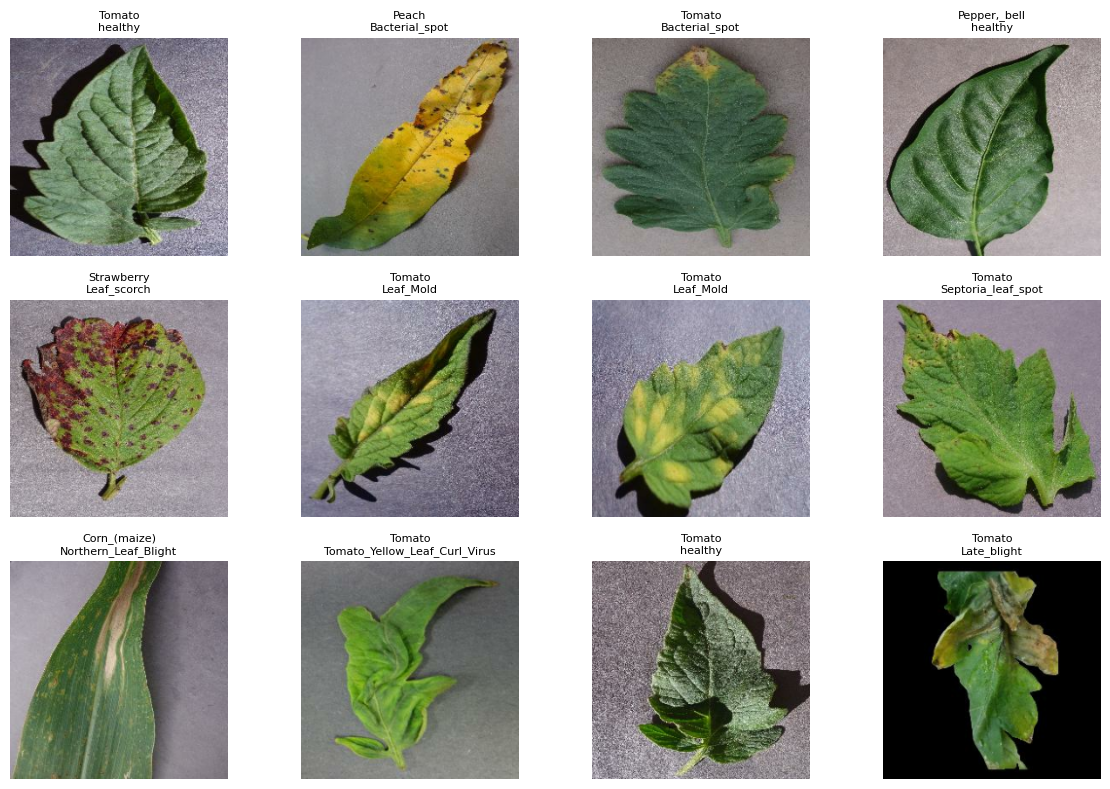

In [3]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]].replace('___', '\n'), fontsize=8)
        plt.axis("off")
plt.tight_layout()
plt.show()

## 4-qadam. Modelni qurish (Transfer Learning)

**Transfer learning nima?** Noldan o'qitish o'rniga, ImageNet'dagi 1,2 million+ rasmda oldindan o'qitilgan modeldan foydalanamiz. U allaqachon chiziq, rang, tekstura kabi belgilarni taniydi. Biz faqat oxirgi qatlamni o'z vazifamizga (38 sinf) moslab o'qitamiz. Bu kam vaqt va kam ma'lumot bilan yuqori natija beradi.

**Nega MobileNetV2?** U telefonlar uchun ishlab chiqilgan yengil arxitektura — kelajakda fermer telefonida ishlaydigan ilova uchun mos.

**Data augmentation** — rasmlarni tasodifiy aylantirish, ag'darish va kattalashtirish. Bu modelni "yodlab olish"dan (overfitting) himoya qiladi.

In [4]:
from tensorflow.keras import layers

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="augmentation")

base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False   # hozircha asosiy modelni "muzlatamiz"

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = augment(inputs)
x = layers.Rescaling(1./127.5, offset=-1)(x)   # piksellarni [-1, 1] oralig'iga o'tkazish
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5-qadam. O'qitish

Har bir **epoch** — model barcha train suratlarini bir marta ko'rib chiqishi. T4 GPU'da bir epoch odatda bir necha daqiqa oladi.

In [5]:
EPOCHS = 5
early_stop = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[early_stop])

Epoch 1/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 99s 130ms/step - accuracy: 0.7995 - loss: 0.7250 - val_accuracy: 0.9056 - val_loss: 0.3360
Epoch 2/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 79s 116ms/step - accuracy: 0.8951 - loss: 0.3382 - val_accuracy: 0.9194 - val_loss: 0.2610
Epoch 3/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 80s 118ms/step - accuracy: 0.9083 - loss: 0.2914 - val_accuracy: 0.9301 - val_loss: 0.2251
Epoch 4/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 81s 119ms/step - accuracy: 0.9165 - loss: 0.2561 - val_accuracy: 0.9275 - val_loss: 0.2229
Epoch 5/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 81s 119ms/step - accuracy: 0.9178 - loss: 0.2474 - val_accuracy: 0.9316 - val_loss: 0.2118


## 6-qadam. Fine-tuning (ixtiyoriy, lekin natijani yaxshilaydi)

Endi asosiy modelning oxirgi qatlamlarini "eritib", juda kichik o'qish tezligi (learning rate) bilan qo'shimcha o'qitamiz. Kichik tezlik oldindan o'rganilgan bilimni buzmaslik uchun kerak.

In [6]:
base.trainable = True
for layer in base.layers[:-30]:     # faqat oxirgi 30 ta qatlam o'qitiladi
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=[early_stop])

Epoch 1/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 116s 155ms/step - accuracy: 0.8489 - loss: 0.5305 - val_accuracy: 0.9343 - val_loss: 0.1983
Epoch 2/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 104s 153ms/step - accuracy: 0.9150 - loss: 0.2625 - val_accuracy: 0.9437 - val_loss: 0.1697
Epoch 3/3
679/679 ━━━━━━━━━━━━━━━━━━━━ 104s 153ms/step - accuracy: 0.9301 - loss: 0.2144 - val_accuracy: 0.9472 - val_loss: 0.1577


## 7-qadam. O'qish grafiklari

Agar **train** aniqligi o'sib, **validation** aniqligi pasaysa — bu overfitting belgisi.

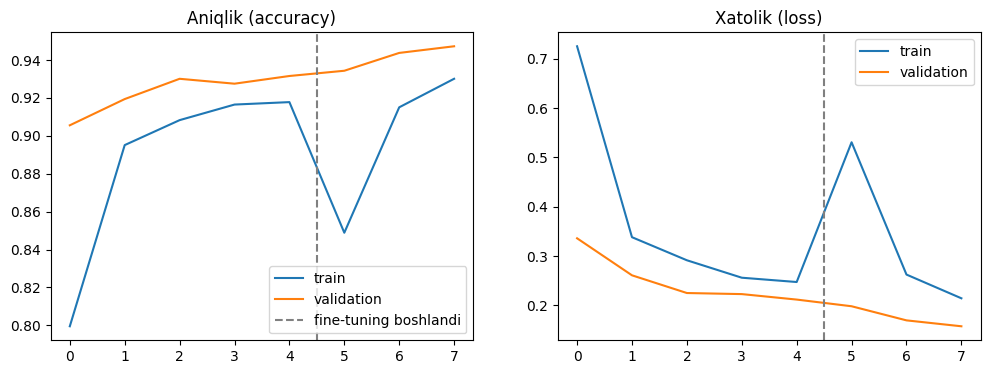

In [7]:
acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss = history.history['loss'] + history_ft.history['loss']
val_loss = history.history['val_loss'] + history_ft.history['val_loss']
split_at = len(history.history['accuracy'])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(acc, label='train'); ax[0].plot(val_acc, label='validation')
ax[0].axvline(split_at - 0.5, ls='--', c='gray', label='fine-tuning boshlandi')
ax[0].set_title('Aniqlik (accuracy)'); ax[0].legend()
ax[1].plot(loss, label='train'); ax[1].plot(val_loss, label='validation')
ax[1].axvline(split_at - 0.5, ls='--', c='gray')
ax[1].set_title('Xatolik (loss)'); ax[1].legend()
plt.show()

## 8-qadam. Halol baholash (test to'plami)

📌 **Bu kataklar natijasini yozib oling** — suhbatda aynan shu raqamlarni aytasiz.

In [8]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ TEST ANIQLIGI: {test_acc*100:.2f}%")

y_true, y_pred = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)
print("Test suratlari soni:", len(y_true))

85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.9465 - loss: 0.1760

✅ TEST ANIQLIGI: 94.65%
Test suratlari soni: 5440


In [9]:
# Model eng ko'p adashtirgan sinf juftliklari
errors = Counter((class_names[t], class_names[p]) for t, p in zip(y_true, y_pred) if t != p)
print("Eng ko'p uchragan xatolar (haqiqiy → model javobi):")
for (t, p), n in errors.most_common(8):
    print(f"  {n:3d} ta:  {t}  →  {p}")

# Har bir sinf bo'yicha batafsil hisobot
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=range(NUM_CLASSES),
                            target_names=class_names, digits=3, zero_division=0))

Eng ko'p uchragan xatolar (haqiqiy → model javobi):
   13 ta:  Tomato___Early_blight  →  Tomato___Target_Spot
   12 ta:  Tomato___Septoria_leaf_spot  →  Tomato___Target_Spot
   11 ta:  Tomato___Spider_mites Two-spotted_spider_mite  →  Tomato___healthy
   11 ta:  Tomato___Late_blight  →  Tomato___Target_Spot
   11 ta:  Tomato___Early_blight  →  Tomato___Septoria_leaf_spot
   10 ta:  Pepper,_bell___Bacterial_spot  →  Pepper,_bell___healthy
    9 ta:  Tomato___Early_blight  →  Tomato___Late_blight
    9 ta:  Tomato___Spider_mites Two-spotted_spider_mite  →  Tomato___Target_Spot
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.951     0.892     0.921        65
                                 Apple___Black_rot      0.985     0.955     0.970        67
                          Apple___Cedar_apple_rust      1.000     0.966     0.982        29
                                   Apple___health

## 9-qadam. O'zim olgan surat bilan sinash

Telefoningizda pomidor, kartoshka, olma yoki uzum bargini **oddiy fonda** suratga oling va shu yerga yuklang.

⚠️ Natija test aniqligidan pastroq chiqsa, bu kutilgan hol — sababini 11-qadamda tushuntiraman. Aynan shu kuzatuv suhbatda juda kuchli fikr bo'ladi.

Saving blob.jpeg to blob.jpeg


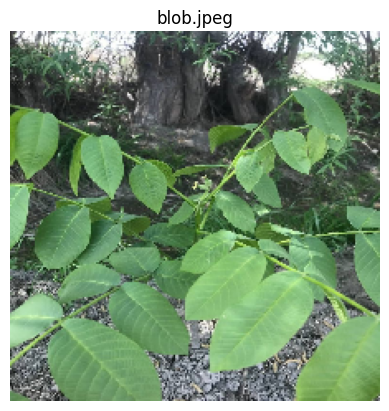

  Apple___Apple_scab                                       44.7%
  Tomato___Late_blight                                     27.4%
  Soybean___healthy                                        19.8%


In [10]:
from google.colab import files
uploaded = files.upload()

for fname in uploaded:
    img = tf.keras.utils.load_img(fname, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)[None, ...]
    probs = model.predict(arr, verbose=0)[0]
    top3 = probs.argsort()[-3:][::-1]
    plt.imshow(img); plt.axis('off'); plt.title(fname); plt.show()
    for i in top3:
        print(f"  {class_names[i]:<55} {probs[i]*100:5.1f}%")

## 10-qadam. Saqlash va telefon uchun eksport (TensorFlow Lite)

In [11]:
import os
model.save("plant_disease_model.keras")

try:
    model.export("plant_savedmodel")
    converter = tf.lite.TFLiteConverter.from_saved_model("plant_savedmodel")
    converter.optimizations = [tf.lite.Optimize.DEFAULT]   # hajmni kichraytirish
    tflite_model = converter.convert()
    with open("plant_disease_model.tflite", "wb") as f:
        f.write(tflite_model)
    print(f"Keras model: {os.path.getsize('plant_disease_model.keras')/1e6:.1f} MB")
    print(f"TFLite model (telefon uchun): {len(tflite_model)/1e6:.1f} MB")
except Exception as e:
    print("TFLite eksportida xato:", e)

with open("class_names.txt", "w") as f:
    f.write("\n".join(class_names))

Saved artifact at 'plant_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  133965068826192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068825808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068817744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068826000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965065879184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965065878992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965066092176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068818320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068379984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068377488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068

In [12]:
# Telefon uchun model: augmentation qatlamisiz (u faqat o'qitishda kerak)
inf_in = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inf_in
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.InputLayer) or layer.name == "augmentation":
        continue
    x = layer(x)
inference_model = tf.keras.Model(inf_in, x)

# Tekshiruv: yangi model eski model bilan bir xil javob beradimi?
for images, _ in test_ds.take(1):
    same = np.allclose(model.predict(images[:4], verbose=0),
                       inference_model.predict(images[:4], verbose=0), atol=1e-4)
print("Natijalar bir xil:", same)

# TFLite'ga aylantirish
inference_model.export("plant_savedmodel_inference")
converter = tf.lite.TFLiteConverter.from_saved_model("plant_savedmodel_inference")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open("plant_disease_model.tflite", "wb") as f:
    f.write(tflite_model)
print(f"TFLite model (telefon uchun): {len(tflite_model)/1e6:.1f} MB")

Natijalar bir xil: True
Saved artifact at 'plant_savedmodel_inference'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_165')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  133965068826000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965065879184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965065878992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965066092176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068818320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068379984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068377488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068606480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068385744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133965068380176: TensorSpec(shape=(), dtype=t

## 11-qadam. Xulosa va cheklovlar (suhbat uchun eng muhim qism)

**Natija:** test aniqligi — yuqoridagi 8-qadamdagi raqam.

**Halol cheklovlar:**
1. **Laboratoriya suratlari.** PlantVillage suratlari bir xil fonda, yaxshi yorug'likda olingan. PlantVillage asosida ishlagan Mohanty va hamkasblari (2016) ham shunday modellar boshqa manbadan olingan suratlarda ancha past natija ko'rsatishini qayd etgan. Dalada — soya, tuproq, boshqa barglar fonida — aniqlik pasayadi.
2. **Mahalliy ekinlar yo'q.** To'plamda paxta, bug'doy kabi O'zbekiston uchun asosiy ekinlar yo'q. Pomidor, kartoshka, olma, uzum bor — ular ham bizda keng ekiladi.
3. **Kasallik ≠ yechim.** Model faqat nomini aytadi; fermerga nima qilish kerakligini aytish uchun agronomlar bilan ishlash kerak.

**Keyingi qadamlar:**
- O'zbekiston dalalaridan, agronomlar bilan birga, mahalliy suratlar to'plash
- Real dala suratlarida qayta o'qitish va sinash
- TFLite modelni oddiy mobil ilova yoki Telegram botga ulash
- Sug'orish tavsiyalari (tuproq namligi + ob-havo) bilan birlashtirish